# AT5

1 - Carregamento

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2 - Quantidade de Linhas e Colunas

In [21]:
linhas, colunas = df.shape
print(f'Número de linhas  : {linhas}')
print(f'Número de colunas : {colunas}')

Número de linhas  : 891
Número de colunas : 12


3 - Tipo de Dado de Cada Variável

In [22]:
print('Tipos de dados por coluna:')
print(df.dtypes)
print()
print('Valores ausentes por coluna:')
print(df.isnull().sum())

Tipos de dados por coluna:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Valores ausentes por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


4 - Resumo Estatístico das Variáveis

In [23]:
print('=== Variáveis numéricas ===')
display(df.describe())

print('\n=== Variáveis categóricas ===')
display(df.describe(include='object'))

=== Variáveis numéricas ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== Variáveis categóricas ===


C:\Users\Pichau\AppData\Local\Temp\ipykernel_6716\1525994492.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


5 - Tabela de Frequência e Gráfico Para a Variável

5.1 - Tabela de Frequência

In [24]:
freq_survived = df['Survived'].value_counts().reset_index()
freq_survived.columns = ['Survived', 'Frequência']
freq_survived['Survived'] = freq_survived['Survived'].map({0: 'Não sobreviveu (0)', 1: 'Sobreviveu (1)'})
freq_survived['Frequência Relativa (%)'] = (freq_survived['Frequência'] / len(df) * 100).round(2)
print(freq_survived.to_string(index=False))

          Survived  Frequência  Frequência Relativa (%)
Não sobreviveu (0)         549                    61.62
    Sobreviveu (1)         342                    38.38


5.2 - Gráfico de Barras para Survival

Justificativa: O gráfico de barras é o tipo mais adequado para variáveis categóricas/binárias como Survived (0 ou 1). Ele permite comparar visualmente de forma direta a quantidade de passageiros em cada categoria, sendo de fácil leitura e interpretação. Alternativas como o gráfico de pizza também seriam válidas, mas o gráfico de barras facilita a comparação de magnitudes absolutas.

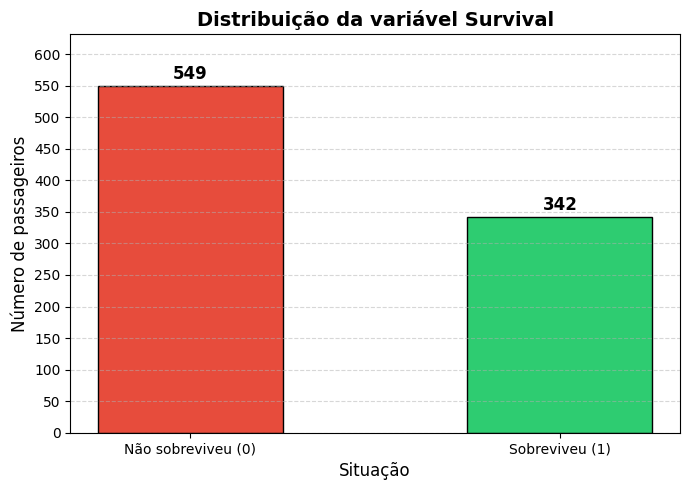

In [25]:
contagens = df['Survived'].value_counts().sort_index()
rotulos = ['Não sobreviveu (0)', 'Sobreviveu (1)']
cores = ['#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(rotulos, contagens.values, color=cores, edgecolor='black', width=0.5)

for bar, val in zip(bars, contagens.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(val),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distribuição da variável Survival', fontsize=14, fontweight='bold')
ax.set_xlabel('Situação', fontsize=12)
ax.set_ylabel('Número de passageiros', fontsize=12)
ax.set_ylim(0, contagens.max() * 1.15)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

6 - Quantas pessoas sobreviveram?

In [26]:
total = len(df)
sobreviventes = df['Survived'].sum()
nao_sobreviventes = total - sobreviventes
perc_sobrev = sobreviventes / total * 100

print(f'Total de passageiros   : {total}')
print(f'Sobreviventes          : {sobreviventes} ({perc_sobrev:.1f}%)')
print(f'Não sobreviventes      : {nao_sobreviventes} ({100 - perc_sobrev:.1f}%)')

classe_mais_freq = df['Pclass'].value_counts().idxmax()
print(f'\nClasse mais frequente  : {classe_mais_freq}ª classe '
      f'({df["Pclass"].value_counts()[classe_mais_freq]} passageiros)')

Total de passageiros   : 891
Sobreviventes          : 342 (38.4%)
Não sobreviventes      : 549 (61.6%)

Classe mais frequente  : 3ª classe (491 passageiros)


7 - Relação Entre as Variáveis "Sex" e "Survival"

7.1 - Tabela de Frequência Cruzada

In [27]:
tabela_cruzada = pd.crosstab(
    df['Sex'],
    df['Survived'].map({0: 'Não sobreviveu', 1: 'Sobreviveu'}),
    margins=True,
    margins_name='Total'
)
print('Tabela de frequência — Sex × Survived')
print(tabela_cruzada)

print()
tabela_pct = pd.crosstab(
    df['Sex'],
    df['Survived'].map({0: 'Não sobreviveu', 1: 'Sobreviveu'}),
    normalize='index'
) * 100
print('Tabela de frequência relativa por sexo (%)')
print(tabela_pct.round(1))

Tabela de frequência — Sex × Survived
Survived  Não sobreviveu  Sobreviveu  Total
Sex                                        
female                81         233    314
male                 468         109    577
Total                549         342    891

Tabela de frequência relativa por sexo (%)
Survived  Não sobreviveu  Sobreviveu
Sex                                 
female              25.8        74.2
male                81.1        18.9


7.2 - Gráfico de Barras Agrupado: Sex x Survival

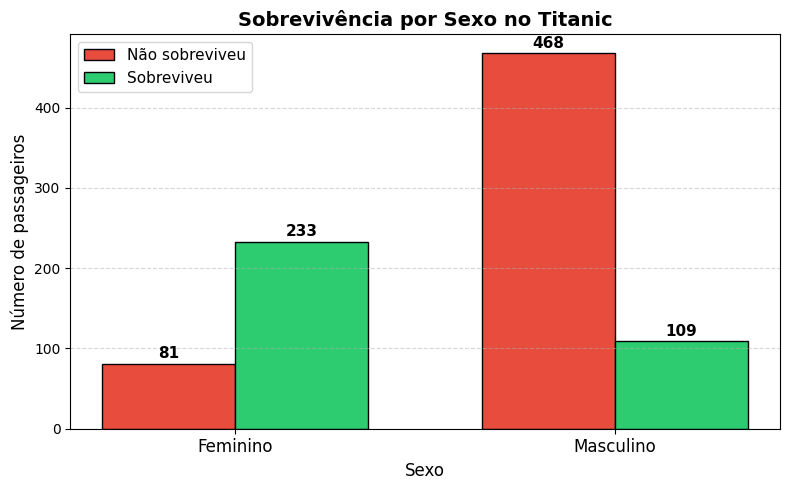

In [28]:
sobrev_por_sexo = df.groupby(['Sex', 'Survived']).size().unstack()
sobrev_por_sexo.columns = ['Não sobreviveu', 'Sobreviveu']
sobrev_por_sexo.index = ['Feminino', 'Masculino']

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(sobrev_por_sexo))
largura = 0.35

bars1 = ax.bar([i - largura/2 for i in x], sobrev_por_sexo['Não sobreviveu'],
               width=largura, label='Não sobreviveu', color='#e74c3c', edgecolor='black')
bars2 = ax.bar([i + largura/2 for i in x], sobrev_por_sexo['Sobreviveu'],
               width=largura, label='Sobreviveu', color='#2ecc71', edgecolor='black')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(sobrev_por_sexo.index, fontsize=12)
ax.set_title('Sobrevivência por Sexo no Titanic', fontsize=14, fontweight='bold')
ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('Número de passageiros', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

7.3 - As mulheres sobreviveram mais que homens?

In [29]:
taxa_sobrev = df.groupby('Sex')['Survived'].mean() * 100
print('Taxa de sobrevivência por sexo:')
for sexo, taxa in taxa_sobrev.items():
    nome = 'Feminino' if sexo == 'female' else 'Masculino'
    print(f'  {nome}: {taxa:.1f}%')

print()
print('R: Sim, as mulheres sobreviveram em proporção muito maior que os homens')
print(f'A taxa de sobrevivência feminina ({taxa_sobrev["female"]:.1f}%) foi '
      f'{taxa_sobrev["female"] / taxa_sobrev["male"]:.1f}x maior que a masculina ({taxa_sobrev["male"]:.1f}%).')
print('Isso reflete a política "mulheres e crianças primeiro" adotada durante o naufragio.')

Taxa de sobrevivência por sexo:
  Feminino: 74.2%
  Masculino: 18.9%

R: Sim, as mulheres sobreviveram em proporção muito maior que os homens
A taxa de sobrevivência feminina (74.2%) foi 3.9x maior que a masculina (18.9%).
Isso reflete a política "mulheres e crianças primeiro" adotada durante o naufragio.


8 - Distribuição das Idades dos Passageiros

8.1 - Gráfico de Distribuição de Idades

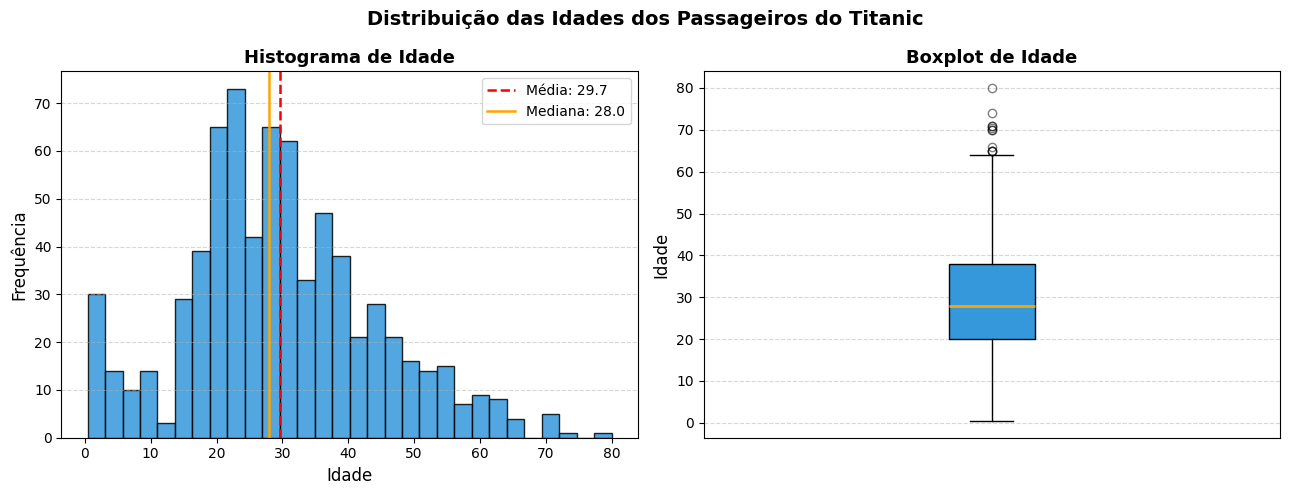

In [30]:
idades = df['Age'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(idades, bins=30, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].axvline(idades.mean(),   color='red',    linestyle='--', linewidth=1.8, label=f'Média: {idades.mean():.1f}')
axes[0].axvline(idades.median(), color='orange', linestyle='-',  linewidth=1.8, label=f'Mediana: {idades.median():.1f}')
axes[0].set_title('Histograma de Idade', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Idade', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

bp = axes[1].boxplot(idades, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#3498db', color='black'),
                     medianprops=dict(color='orange', linewidth=2),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', color='gray', alpha=0.5))
axes[1].set_title('Boxplot de Idade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Idade', fontsize=12)
axes[1].set_xticks([])
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribuição das Idades dos Passageiros do Titanic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

8.2 - Análise da Distribuição de Idades

In [31]:
print('=== Estatísticas da variável Age ===')
print(f'Total de registros    : {len(df)}')
print(f'Valores ausentes (Age): {df["Age"].isnull().sum()}')
print(f'Valores preenchidos   : {int(idades.count())}')
print()
print(f'Média    : {idades.mean():.2f} anos')
print(f'Mediana  : {idades.median():.2f} anos')
print(f'Desvio   : {idades.std():.2f} anos')
print(f'Mínimo   : {idades.min():.0f} anos')
print(f'Máximo   : {idades.max():.0f} anos')
print(f'Assimetria (skewness): {idades.skew():.3f}')
print()

jovens  = (idades < 30).sum()
idosos  = (idades >= 60).sum()
print(f'Passageiros com menos de 30 anos : {jovens} ({jovens/len(idades)*100:.1f}%)')
print(f'Passageiros com 60 anos ou mais  : {idosos} ({idosos/len(idades)*100:.1f}%)')
print()
print('--- Conclusão ---')
print('A distribuição das idades NÃO é perfeitamente simétrica: apresenta')
print('assimetria positiva (cauda à direita), indicando que havia mais')
print('passageiros jovens que idosos. A mediana (28 anos) é menor que a')
print('média (~29,7 anos), confirmando essa assimetria leve.')
print('A maioria dos passageiros era JOVEM, com concentração na faixa de 20 a 35 anos.')

=== Estatísticas da variável Age ===
Total de registros    : 891
Valores ausentes (Age): 177
Valores preenchidos   : 714

Média    : 29.70 anos
Mediana  : 28.00 anos
Desvio   : 14.53 anos
Mínimo   : 0 anos
Máximo   : 80 anos
Assimetria (skewness): 0.389

Passageiros com menos de 30 anos : 384 (53.8%)
Passageiros com 60 anos ou mais  : 26 (3.6%)

--- Conclusão ---
A distribuição das idades NÃO é perfeitamente simétrica: apresenta
assimetria positiva (cauda à direita), indicando que havia mais
passageiros jovens que idosos. A mediana (28 anos) é menor que a
média (~29,7 anos), confirmando essa assimetria leve.
A maioria dos passageiros era JOVEM, com concentração na faixa de 20 a 35 anos.
